<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 52 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Capture-Recapture: the Hypergeometric 🐟</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Tag 100 fish, release them, then net 30 more and count how many carry a tag. Drawing without replacement is the hypergeometric distribution, and it lets ecologists estimate a population they can never fully count.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/wildlife_capture_recapture.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"wildlife_capture_recapture.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 6)


,expedition_id,location_zone,total_population_N,total_tagged_K,sample_size_n,tagged_fish_count
0,EXP_3000,North_Basin,500,100,30,4
1,EXP_3001,South_Basin,500,100,30,7
2,EXP_3002,East_Estuary,500,100,30,2
3,EXP_3003,North_Basin,500,100,30,7
4,EXP_3004,North_Basin,500,100,30,10


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · DRAWING WITHOUT REPLACEMENT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The hypergeometric model</div>
<div style="color:#4a5578;margin-top:6px">Net 30 fish from a lake of 500, of which 100 are tagged. The number of tagged fish in the catch is hypergeometric, because each fish is removed (no replacement), so the odds shift with every draw.</div>
</div>

In [2]:
N = int(df.total_population_N.iloc[0]); K = int(df.total_tagged_K.iloc[0]); n = int(df.sample_size_n.iloc[0])
x = df["tagged_fish_count"]
print(f"population N = {N}, tagged K = {K}, sample n = {n}")
print(f"observed mean tagged in catch = {x.mean():.3f}")
print(f"hypergeometric mean = n K / N = {n*K/N:.3f}")
print(f"hypergeometric variance = {stats.hypergeom.var(N,K,n):.3f}  (observed {x.var():.3f})")

population N = 500, tagged K = 100, sample n = 30
observed mean tagged in catch = 5.905
hypergeometric mean = n K / N = 6.000
hypergeometric variance = 4.521  (observed 4.739)


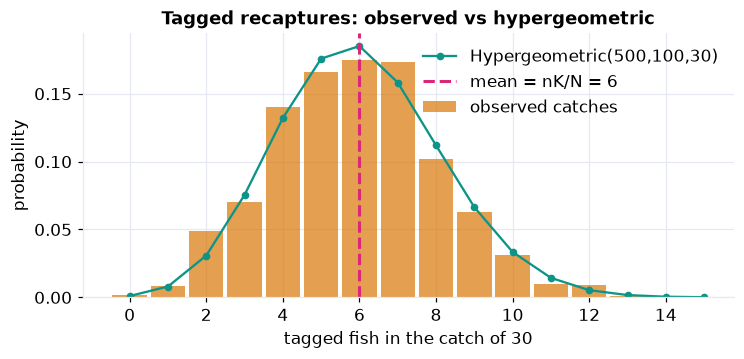

In [3]:
fig,ax=plt.subplots(figsize=(7,3.4))
k=np.arange(0,16)
obs=x.value_counts(normalize=True).sort_index()
ax.bar(obs.index,obs.values,color=AMBER,alpha=0.7,width=0.9,label="observed catches")
ax.plot(k, stats.hypergeom.pmf(k,N,K,n),"o-",color=TEAL,ms=4,label="Hypergeometric(500,100,30)")
ax.axvline(n*K/N,color=PINK,ls="--",lw=2,label=f"mean = nK/N = {n*K/N:.0f}")
ax.set_xlabel("tagged fish in the catch of 30"); ax.set_ylabel("probability"); ax.set_title("Tagged recaptures: observed vs hypergeometric"); ax.legend()
plt.tight_layout(); plt.show()

The hypergeometric PMF lands on the data: a catch of 30 contains about **6** tagged fish on average, exactly n&middot;K/N. Because the lake is finite and fish are not thrown back, this is hypergeometric, not binomial.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · WITHOUT vs WITH REPLACEMENT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The finite-population correction</div>
<div style="color:#4a5578;margin-top:6px">If the lake were infinite (or fish were tossed back), the count would be Binomial(30, K/N). The hypergeometric is slightly TIGHTER, the finite-population correction shrinks the variance.</div>
</div>

In [4]:
p = K/N
print(f"hypergeometric variance = {stats.hypergeom.var(N,K,n):.4f}")
print(f"binomial      variance = {stats.binom.var(n,p):.4f}  (with replacement)")
fpc = (N-n)/(N-1)
print(f"finite-population correction (N-n)/(N-1) = {fpc:.4f}")
print(f"binomial var x FPC = {stats.binom.var(n,p)*fpc:.4f}  (= hypergeometric var)")

hypergeometric variance = 4.5210
binomial      variance = 4.8000  (with replacement)
finite-population correction (N-n)/(N-1) = 0.9419
binomial var x FPC = 4.5210  (= hypergeometric var)


Both share the same mean (6), but drawing without replacement makes outcomes <em>less</em> variable: the variance carries a finite-population correction factor (N&minus;n)/(N&minus;1) &#8776; 0.94. When the sample is tiny relative to the population, this factor approaches 1 and the binomial becomes a fine approximation.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · ESTIMATE THE UNCOUNTABLE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The Lincoln-Petersen method</div>
<div style="color:#4a5578;margin-top:6px">The real payoff: invert the model to estimate the unknown population N. If a fraction k/n of the catch is tagged, and K fish are tagged overall, then N_hat = K n / k. This is how you count fish you can never see all at once.</div>
</div>

In [5]:
# Lincoln-Petersen (filter the rare k=0 catches where the simple estimator is undefined)
k = df.tagged_fish_count
lp = (K*n/k[k>0])
print(f"Lincoln-Petersen N_hat = K n / k, mean over expeditions = {lp.mean():.1f}  (true N = {N})")
# Chapman estimator (bias-corrected, handles k=0)
chap = (K+1)*(n+1)/(k+1) - 1
print(f"Chapman estimator (bias-corrected), mean = {chap.mean():.1f}  (true N = {N})")

Lincoln-Petersen N_hat = K n / k, mean over expeditions = 608.9  (true N = 500)
Chapman estimator (bias-corrected), mean = 513.2  (true N = 500)


Each expedition gives a population estimate. The simple Lincoln-Petersen N_hat = K&middot;n/k <strong>overshoots</strong> (mean &#8776; 609), because dividing by a small recapture count k inflates it, a real bias. The <strong>bias-corrected Chapman estimator</strong> fixes this and lands near the true **N = 500** (mean &#8776; 513). This is the quiet magic of capture-recapture: a distribution about a sample, run backward, measures a whole that no one could count directly, the method behind wildlife censuses, software bug estimation, and even counting undocumented populations.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Recaptures are hypergeometric because we sample without replacement. We fit the model (mean 6), saw the finite-population correction shrink its variance below the binomial, and inverted it with the Chapman estimator to recover the unseen population N &#8776; 500 (the simple Lincoln-Petersen formula overshoots). Sampling without replacement, run backward, becomes a census.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>